# Mustache Detector v3
Pipeline som automatiskt:
1. Skapar dataset med män + kvinnor
2. Tränar en första modell
3. Använder modellen för att hitta och flytta felmärkta clean-bilder
4. Tränar om på rensad data
5. Sparar slutlig modell

In [ ]:
import pandas as pd
import os
import shutil
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix



TensorFlow: 2.16.2


## 1. Ladda och filtrera data

In [46]:
labels     = pd.read_csv('data/list_attr_celeba.csv')
source_dir = 'data/img/img_align_celeba'

men   = labels[labels['Male'] ==  1]
women = labels[labels['Male'] == -1]

mustache_df = men[men['Mustache'] == 1]
men_clean   = men[men['Mustache'] == -1]
women_black_hair = women[
    (women['Mustache'] == -1) & 
    (women['Black_Hair'] == 1)
].sample(n=2000, random_state=42)

women_other = women[
    (women['Mustache'] == -1) & 
    (women['Black_Hair'] == -1)
].sample(n=1000, random_state=42)

women_clean = pd.concat([women_black_hair, women_other])
clean_df    = pd.concat([men_clean, women_clean])

# Första modellen — 6000 per klass (städas sedan i steg 5)
mustache_sample = mustache_df.sample(n=5000, random_state=42)
clean_sample    = clean_df.sample(n=5000, random_state=42)

print(f'Mustasch: {len(mustache_sample)}')
print(f'Clean:    {len(clean_sample)}')


Mustasch: 5000
Clean:    5000


## 2. Kopiera bilder till dataset_v3

In [9]:
MUSTACHE_DIR = 'data/dataset_v3/mustache'
CLEAN_DIR    = 'data/dataset_v3/clean'

In [49]:
MUSTACHE_DIR = 'data/dataset_v3/mustache'
CLEAN_DIR    = 'data/dataset_v3/clean'

# Rensa och skapa mappar
if os.path.exists('data/dataset_v3'):
    shutil.rmtree('data/dataset_v3')
os.makedirs(MUSTACHE_DIR)
os.makedirs(CLEAN_DIR)

for filename in mustache_sample['image_id']:
    src = os.path.join(source_dir, filename)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(MUSTACHE_DIR, filename))

for filename in clean_sample['image_id']:
    src = os.path.join(source_dir, filename)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(CLEAN_DIR, filename))

print(f'Mustasch: {len(os.listdir(MUSTACHE_DIR))}')
print(f'Clean:    {len(os.listdir(CLEAN_DIR))}')

Mustasch: 5000
Clean:    5000


## 3. Ladda dataset och bygg modell

In [24]:
IMG_SIZE   = (178, 178)
BATCH_SIZE = 32

def load_datasets(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset='training',
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset='validation',
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary'
    )
    return train_ds, val_ds

def build_model():
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ])

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    return model

def train_model(model, train_ds, val_ds, epochs=35, patience=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop]
    )
    return history

print('Funktioner redo!')

Funktioner redo!


## 4. Träna första modellen

In [25]:
train_ds, val_ds = load_datasets('data/dataset_v3')
print('Klasser:', train_ds.class_names)

model_v1 = build_model()
history1 = train_model(model_v1, train_ds, val_ds)

loss, acc = model_v1.evaluate(val_ds)
print(f'\nFörsta modellen accuracy: {acc*100:.1f}%')

Found 10952 files belonging to 2 classes.
Using 8762 files for training.
Found 10952 files belonging to 2 classes.
Using 2190 files for validation.
Klasser: ['clean', 'mustache']
Epoch 1/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 108s 386ms/step - accuracy: 0.6306 - loss: 0.6227 - val_accuracy: 0.7553 - val_loss: 0.5066
Epoch 2/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 404ms/step - accuracy: 0.8503 - loss: 0.3425 - val_accuracy: 0.9073 - val_loss: 0.2306
Epoch 3/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 110s 401ms/step - accuracy: 0.8910 - loss: 0.2643 - val_accuracy: 0.9174 - val_loss: 0.2047
Epoch 4/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 109s 398ms/step - accuracy: 0.9073 - loss: 0.2186 - val_accuracy: 0.9274 - val_loss: 0.1817
Epoch 5/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 112s 408ms/step - accuracy: 0.9149 - loss: 0.2066 - val_accuracy: 0.9338 - val_loss: 0.1550
Epoch 6/35
274/274 ━━━━━━━━━━━━━━━━━━━━ 112s 407ms/step - accuracy: 0.9246 - loss: 0.1900 - val_accuracy: 0.9370 - val_loss: 0.1510
Epoch 7/35
274/274 ━━━━━━━━━━

## 5. Hitta och flytta felmärkta clean-bilder

In [14]:
# DEL 1 — Hitta felmärkta och visa dem

NOISE_THRESHOLD = 0.70

clean_files = os.listdir(CLEAN_DIR)
scores = []

for i, fname in enumerate(clean_files):
    path = os.path.join(CLEAN_DIR, fname)
    img  = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    arr  = np.expand_dims(tf.keras.utils.img_to_array(img), axis=0)
    prob = float(model_v1.predict(arr, verbose=0)[0][0])
    scores.append((fname, prob))
    if (i + 1) % 1000 == 0:
        print(f'{i+1}/{len(clean_files)} klara...')

to_move = [(f, s) for f, s in scores if s > NOISE_THRESHOLD]
print(f'Hittade {len(to_move)} felmärkta bilder (>{NOISE_THRESHOLD*100:.0f}%)')

# Visa topp 25
plt.figure(figsize=(15, 15))
for i, (fname, score) in enumerate(sorted(to_move, key=lambda x: x[1], reverse=True)[:25]):
    img = Image.open(os.path.join(CLEAN_DIR, fname))
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(f'{score*100:.0f}%')
    plt.axis('off')
plt.suptitle('Felmärkta clean-bilder — ser rimligt ut?', fontsize=14)
plt.tight_layout()
plt.show()

1000/5168 klara...
2000/5168 klara...
3000/5168 klara...
4000/5168 klara...
5000/5168 klara...
Hittade 0 felmärkta bilder (>70%)


<Figure size 1500x1500 with 0 Axes>

In [ ]:
# DEL 2 — Flytta och balansera

for fname, score in to_move:
    shutil.move(os.path.join(CLEAN_DIR, fname), os.path.join(MUSTACHE_DIR, fname))

print(f'Flyttade {len(to_move)} felmärkta → mustache')

already_used = set(os.listdir(CLEAN_DIR)) | set(os.listdir(MUSTACHE_DIR))
women_pool   = women[(women['Mustache'] == -1) & (women['Black_Hair'] == 1)]
women_pool   = women_pool[~women_pool['image_id'].isin(already_used)]

n_mustache = len(os.listdir(MUSTACHE_DIR))
n_clean    = len(os.listdir(CLEAN_DIR))
n_needed   = n_mustache - n_clean

print(f'Behöver {n_needed} fler bilder i clean för balans')

fill = women_pool.sample(n=n_needed, random_state=99)

for filename in fill['image_id']:
    src = os.path.join(source_dir, filename)
    dst = os.path.join(CLEAN_DIR, filename)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f'Clean nu:    {len(os.listdir(CLEAN_DIR))}')
print(f'Mustache nu: {len(os.listdir(MUSTACHE_DIR))}')

Flyttade 206 felmärkta → mustache


NameError: name 'clean_sample' is not defined

## 6. Träna om på rensad data

In [54]:
train_ds2, val_ds2 = load_datasets('data/dataset_v3')

print(f'Mustasch: {len(os.listdir(MUSTACHE_DIR))}')
print(f'Clean:    {len(os.listdir(CLEAN_DIR))}')

model_v2 = build_model()
history2 = train_model(model_v2, train_ds2, val_ds2)

loss, acc = model_v2.evaluate(val_ds2)
print(f'\nSlutlig modell accuracy: {acc*100:.1f}%')

Found 11052 files belonging to 2 classes.
Using 8842 files for training.
Found 11052 files belonging to 2 classes.
Using 2210 files for validation.
Mustasch: 5526
Clean:    5526
Epoch 1/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 55s 193ms/step - accuracy: 0.5903 - loss: 0.6630 - val_accuracy: 0.7738 - val_loss: 0.5077
Epoch 2/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 54s 194ms/step - accuracy: 0.7645 - loss: 0.4930 - val_accuracy: 0.8670 - val_loss: 0.3325
Epoch 3/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.8201 - loss: 0.4114 - val_accuracy: 0.8724 - val_loss: 0.2980
Epoch 4/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 54s 196ms/step - accuracy: 0.8392 - loss: 0.3702 - val_accuracy: 0.8846 - val_loss: 0.2731
Epoch 5/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 64s 230ms/step - accuracy: 0.8505 - loss: 0.3431 - val_accuracy: 0.8950 - val_loss: 0.2474
Epoch 6/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 56s 203ms/step - accuracy: 0.8499 - loss: 0.3392 - val_accuracy: 0.8833 - val_loss: 0.2732
Epoch 7/35
277/277 ━━━━━━━━━━━━━━━━━

## 7. Utvärdering

NameError: name 'history2' is not defined

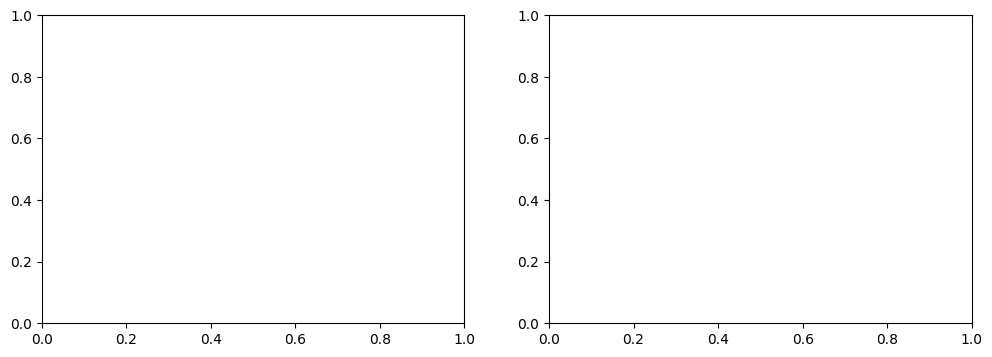

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['accuracy'], label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history2.history['loss'], label='Train')
axes[1].plot(history2.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('presentation/training_curves_mustache.png', dpi=150, bbox_inches='tight')
plt.show()

y_true, y_pred = [], []
for images, labels_batch in val_ds2:
    preds = model_v2.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=val_ds2.class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Mustache Detector v3')
plt.savefig('presentation/confusion_mustache_v3.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Spara modellen

In [26]:
os.makedirs('models', exist_ok=True)
model_v1.save('models/mustache_detector2.keras')
print('Sparad: models/mustache_detector2.keras')

Sparad: models/mustache_detector2.keras
